# Exemplo 3 — RK4 para Sistema de EDOs de Primeira Ordem

**Slide p. 31** — Aplicar RK4 ao sistema acoplado

$$\frac{dy_1}{dt} = -0{,}5\,y_1$$

$$\frac{dy_2}{dt} = 4 - 0{,}3\,y_2 - 0{,}1\,y_1$$

com $y_1(0) = 4$, $y_2(0) = 6$, $h = 0{,}5$, $t \in [0, 2]$.

    t          y1          y2
  0.0    4.000000    6.000000
  0.5    3.115234    6.857670
  1.0    2.426171    7.632106
  1.5    1.889523    8.326886
  2.0    1.471577    8.946865


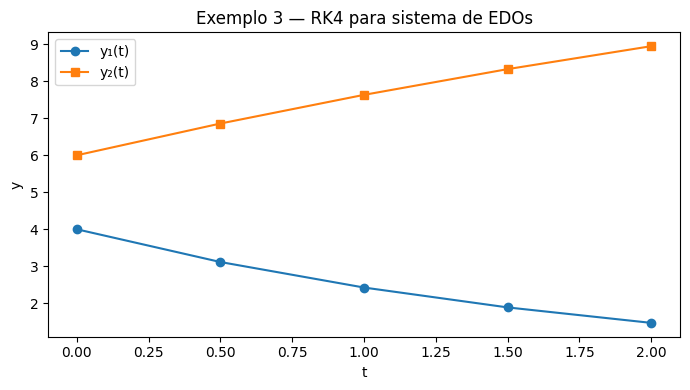

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f1(t, y1, y2):
    return -0.5 * y1

def f2(t, y1, y2):
    return 4 - 0.3*y2 - 0.1*y1

t0, y1_0, y2_0, h = 0.0, 4.0, 6.0, 0.5
t_end = 2.0

t, y1, y2 = t0, y1_0, y2_0
ts, y1s, y2s = [t], [y1], [y2]

while t < t_end - 1e-10:
    k1_1 = f1(t,       y1,              y2)
    k1_2 = f2(t,       y1,              y2)

    k2_1 = f1(t + h/2, y1 + k1_1*h/2,  y2 + k1_2*h/2)
    k2_2 = f2(t + h/2, y1 + k1_1*h/2,  y2 + k1_2*h/2)

    k3_1 = f1(t + h/2, y1 + k2_1*h/2,  y2 + k2_2*h/2)
    k3_2 = f2(t + h/2, y1 + k2_1*h/2,  y2 + k2_2*h/2)

    k4_1 = f1(t + h,   y1 + k3_1*h,    y2 + k3_2*h)
    k4_2 = f2(t + h,   y1 + k3_1*h,    y2 + k3_2*h)

    y1 = y1 + (k1_1 + 2*k2_1 + 2*k3_1 + k4_1) * h / 6
    y2 = y2 + (k1_2 + 2*k2_2 + 2*k3_2 + k4_2) * h / 6
    t  = t + h

    ts.append(t); y1s.append(y1); y2s.append(y2)

print(f"{'t':>5}  {'y1':>10}  {'y2':>10}")
for ti, v1, v2 in zip(ts, y1s, y2s):
    print(f"{ti:>5.1f}  {v1:>10.6f}  {v2:>10.6f}")

plt.figure(figsize=(7, 4))
plt.plot(ts, y1s, 'o-', label='y₁(t)')
plt.plot(ts, y2s, 's-', label='y₂(t)')
plt.xlabel('t'); plt.ylabel('y')
plt.title('Exemplo 3 — RK4 para sistema de EDOs')
plt.legend(); plt.tight_layout(); plt.show()
